## Импорт библиотек

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
warnings.filterwarnings('ignore')

## Загрузка данных

In [3]:
df = pd.read_csv('climat_official.csv', parse_dates=['date'])
era5 = pd.read_csv('ERA5_full.csv', parse_dates=['date'])

In [4]:
df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.25,10.00,10.000,8.00,8.000,0.00,...,0,0,0,0,0,0,0,0,0,0
1,34152,1981-01-01,-0.1,0.4,71.00,10.00,7.500,8.00,7.000,0.00,...,0,0,0,0,0,0,0,0,0,0
2,34163,1981-01-01,-1.0,0.4,80.00,10.00,7.500,8.00,6.250,0.00,...,0,0,0,0,0,0,0,0,0,0
3,34172,1981-01-01,0.4,0.0,70.00,10.00,8.750,8.00,7.250,0.00,...,0,0,0,0,0,0,0,0,0,0
4,34186,1981-01-01,-3.6,1.0,24.50,9.75,8.625,6.25,6.375,2.25,...,0,0,0,0,0,0,0,0,0,0


In [5]:
era5.head()

,Индекс ВМО,date,latitude,longitude,2m_dewpoint_temperature_stream-oper_daily-mean,2m_temperature_0_daily-mean,surface_pressure_0_daily-mean,total_precipitation_0_daily-mean,maximum_2m_temperature_since_previous_post_processing_0_daily-mean,skin_temperature_0_daily-mean,mean_evaporation_rate_0_daily-mean,clear_sky_direct_solar_radiation_at_surface_0_daily-mean,evaporation_0_daily-mean,potential_evaporation_0_daily-mean,convective_precipitation_0_daily-mean,avg_pevr,avg_cpr,total_precipitation_scaled
0,34059,1940-01-01,52.0,43.65,-17.98183,-15.66160,99108.64,0.006866,-15.46342,-15.76063,-6.382252e-08,143130.860,-0.000235,-0.022892,0.0,-0.006360,0.0,-0.059208
1,34059,1940-01-02,52.0,43.65,-25.21587,-22.83079,99859.69,0.000119,-22.02915,-24.17704,2.240773e-07,114577.516,0.000809,-0.005217,0.0,-0.001451,0.0,-0.231404
2,34059,1940-01-03,52.0,43.65,-28.55027,-26.00974,99506.39,0.003672,-25.81016,-27.42121,2.444089e-07,112423.450,0.000887,-0.008524,0.0,-0.002368,0.0,-0.140737
3,34059,1940-01-04,52.0,43.65,-23.95266,-21.39904,99039.92,0.145149,-21.49006,-21.82960,3.162277e-07,105748.640,0.001139,-0.017972,0.0,-0.004992,0.0,3.470007
4,34059,1940-01-05,52.0,43.65,-15.92990,-14.26237,98507.39,0.070214,-14.27793,-15.25153,1.394192e-06,113422.200,0.005017,-0.022017,0.0,-0.006115,0.0,1.557536


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112035 entries, 0 to 112034
Data columns (total 51 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       112035 non-null  int64         
 1   date                                             112035 non-null  datetime64[ns]
 2   Средняя температура воздуха                      112035 non-null  float64       
 3   Количество осадков                               112035 non-null  float64       
 4   Горизонтальная дальность видимости               112035 non-null  float64       
 5   Общее количество облачности                      112035 non-null  float64       
 6   Количество облачности нижнего яруса              112035 non-null  float64       
 7   Форма облаков верхнего яруса                     112035 non-null  float64       
 8   Форма облаков среднего я

In [7]:
df.isna().sum()

Индекс ВМО                                            0
date                                                  0
Средняя температура воздуха                           0
Количество осадков                                    0
Горизонтальная дальность видимости                    0
Общее количество облачности                           0
Количество облачности нижнего яруса                   0
Форма облаков верхнего яруса                          0
Форма облаков среднего яруса                          0
Форма облаков вертикального развития                  0
Слоистые и слоисто-кучевые облака                     0
Слоисто-дожд,разорванно-дождевые облака               0
Высота нижней границы облачности                   1106
Погода между сроками                                  0
Погода в срок наблюдения                              0
Направление ветра                                     0
Средняя скорость ветра                                0
Максимальная скорость ветра                     

In [8]:
df = df.interpolate()

In [9]:
df.isna().sum()

Индекс ВМО                                         0
date                                               0
Средняя температура воздуха                        0
Количество осадков                                 0
Горизонтальная дальность видимости                 0
Общее количество облачности                        0
Количество облачности нижнего яруса                0
Форма облаков верхнего яруса                       0
Форма облаков среднего яруса                       0
Форма облаков вертикального развития               0
Слоистые и слоисто-кучевые облака                  0
Слоисто-дожд,разорванно-дождевые облака            0
Высота нижней границы облачности                   0
Погода между сроками                               0
Погода в срок наблюдения                           0
Направление ветра                                  0
Средняя скорость ветра                             0
Максимальная скорость ветра                        0
Сумма осадков                                 

## Разделение на тренировчную/валидационную/тестовую

In [10]:
df.groupby('Индекс ВМО')['date'].count()

Индекс ВМО
34059    16005
34152    16005
34163    16005
34172    16005
34186    16005
34289    16005
34391    16005
Name: date, dtype: int64

На каждый индекс станции есть день

In [11]:
df.shape

(112035, 51)

In [12]:
df.date.min(), df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-10-26 00:00:00'))

In [13]:
# границы
test_start = df['date'].max() - pd.DateOffset(months=1)
val_start = test_start - pd.DateOffset(months=1)
val_start, test_start

(Timestamp('2024-08-26 00:00:00'), Timestamp('2024-09-26 00:00:00'))

In [14]:
train_df = df[df['date'] < val_start]
val_df = df[(df['date'] >= val_start) & (df['date'] < test_start)]
test_df = df[df['date'] >= test_start]

In [15]:
train_df.shape, val_df.shape, test_df.shape

((111601, 51), (217, 51), (217, 51))

In [16]:
217 / 7

31.0

1 месяц

### Делаем значения Nan чтобы не было утечек

In [17]:
old_val_df = val_df.copy()

In [18]:
test_df_nan = test_df.copy()

In [19]:
cols_to_nan = [c for c in val_df.columns if c not in ['date', 'Индекс ВМО']]

val_df[cols_to_nan] = np.nan
test_df_nan[cols_to_nan] = np.nan

In [20]:
val_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111601,34059,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111602,34152,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111603,34163,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111604,34172,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111605,34186,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
test_df_nan.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111818,34059,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111819,34152,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111820,34163,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111821,34172,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111822,34186,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Добавление лагов

1️⃣ Короткие лаги

lag1, lag2, lag3 — уже есть, ловят недавние изменения

2️⃣ Средние и длинные лаги

lag7, lag14, lag30 — недельная и месячная сезонность

Если будут данные за несколько лет, можно lag365 — годовая повторяемость

3️⃣ Скользящие агрегаты

Среднее: rolling_mean_3, rolling_mean_7, rolling_mean_30

Сумма: rolling_sum_3, rolling_sum_7, rolling_sum_30 (для осадков, облачности)

Максимум/минимум: rolling_max_3, rolling_min_7

4️⃣ Разностные признаки

diff_1 = value_today - value_yesterday

diff_3, diff_7 — показывают ускорение изменения

In [22]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_df = train_val_df.sort_values(['Индекс ВМО', 'date'])

In [24]:
train_val_df.date.min(), train_val_df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [25]:
original_cols = [col for col in df.columns if col not in ['Индекс ВМО', 'date']]

In [26]:
def create_lags(df, index_col='Индекс ВМО', date_col='date'):
    # print(df.date.min(), df.date.max())
    # lagged_df = df.copy()
    #
    # # Выбираем колонки для лагов
    # short_lags = [1, 2, 3]
    # cols_to_short_lag = [col for col in lagged_df.columns if col not in [index_col, date_col]]
    # for lag in short_lags:
    #     for col in cols_to_short_lag:
    #         lagged_df[f'{col}_short_lag{lag}'] = lagged_df.groupby(index_col)[col].shift(lag)
    #
    # return lagged_df

    return df

In [27]:
lagged_df = create_lags(train_val_df)
# lagged_df.tail(40)
lagged_df.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111789,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111796,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111803,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111810,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111817,34391,2024-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
lagged_df.shape

(111818, 51)

### Удаление пропусков для начала лагов

In [29]:
# Для каждой группы находим первую дату без NaN
def first_valid_date_per_group(df, group_col='Индекс ВМО', date_col='date'):
    # Словарь: индекс ВМО - дата первой строки без NaN
    first_dates = {}

    for idx, group in df.groupby(group_col):
        # Проверяем только колонки с NaN
        valid_rows = group[~group.isna().any(axis=1)]
        if not valid_rows.empty:
            first_dates[idx] = valid_rows[date_col].iloc[0]
        else:
            first_dates[idx] = None  # если все строки пустые

    return first_dates


# Используем функцию
first_dates_dict = first_valid_date_per_group(lagged_df)
first_dates_dict

{34059: Timestamp('1981-01-01 00:00:00'),
 34152: Timestamp('1981-01-01 00:00:00'),
 34163: Timestamp('1981-01-01 00:00:00'),
 34172: Timestamp('1981-01-01 00:00:00'),
 34186: Timestamp('1981-01-01 00:00:00'),
 34289: Timestamp('1981-01-01 00:00:00'),
 34391: Timestamp('1981-01-01 00:00:00')}

In [30]:
# Обрезаем каждую группу по дате
cleaned_groups = []
for idx, group in lagged_df.groupby('Индекс ВМО'):
    start_date = first_dates_dict[idx]
    cleaned_group = group[group['date'] >= start_date]
    cleaned_groups.append(cleaned_group)

clean_lagged_df = pd.concat(cleaned_groups).reset_index(drop=True)

In [31]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.250,10.000,10.000,8.000,8.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,34059,1981-01-02,1.6,0.5,61.000,10.000,10.000,8.000,8.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34059,1981-01-03,-0.7,0.0,61.375,8.750,5.000,5.250,4.125,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,34059,1981-01-04,-2.5,0.0,52.375,8.875,5.125,5.375,4.250,1.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,34059,1981-01-05,-0.1,3.2,52.500,10.125,8.875,7.250,7.125,1.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
clean_lagged_df.shape

(111818, 51)

## Конструирование признаков

In [385]:
# clean_lagged_df.describe()

In [33]:
clean_lagged_df

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.250,10.000,10.000,8.000,8.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,34059,1981-01-02,1.6,0.5,61.000,10.000,10.000,8.000,8.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34059,1981-01-03,-0.7,0.0,61.375,8.750,5.000,5.250,4.125,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,34059,1981-01-04,-2.5,0.0,52.375,8.875,5.125,5.375,4.250,1.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,34059,1981-01-05,-0.1,3.2,52.500,10.125,8.875,7.250,7.125,1.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111813,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111814,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111815,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111816,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    clean_lagged_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111818 entries, 0 to 111817
Data columns (total 51 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       111818 non-null  int64         
 1   date                                             111818 non-null  datetime64[ns]
 2   Средняя температура воздуха                      111601 non-null  float64       
 3   Количество осадков                               111601 non-null  float64       
 4   Горизонтальная дальность видимости               111601 non-null  float64       
 5   Общее количество облачности                      111601 non-null  float64       
 6   Количество облачности нижнего яруса              111601 non-null  float64       
 7   Форма облаков верхнего яруса                     111601 non-null  float64       
 8   Форма облаков среднего я

## Разделение на тренировочную/валидационную

In [36]:
df_for_training = clean_lagged_df.copy()

In [46]:
# df_for_training = df_for_training.drop(columns=original_cols)

In [47]:
df_for_training.date.min(), df_for_training.date.max(),

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [392]:
# clean_lagged_df = clean_lagged_df.drop(columns=['date'])

In [50]:
val_start

Timestamp('2024-08-26 00:00:00')

In [51]:
# Разделяем
train_df = df_for_training[df_for_training['date'] < val_start].copy()
val_df = df_for_training[df_for_training['date'] >= val_start].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (111601, 2)
Validation shape: (217, 2)


In [41]:
train_df = train_df.drop(columns=['date'])
val_df_drop_date = val_df.drop(columns=['date'])

In [42]:
y_train = train_df['Средняя температура воздуха']
y_val = val_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_val = val_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train shape: (111601, 49) (111601,)
Validation shape: (217, 49) (217,)


## Предсказательные модели

| ugms               | name                  | kod   | широта     | долгота     |
|-------------------|----------------------|-------|-------|-------|
| ПРИВОЛЖСКОЕ УГМС  | САРАТОВ ЮГО-ВОСТОК   | 34172 | 51.57 | 46.0  |
| ПРИВОЛЖСКОЕ УГМС  | ОКТЯБРЬСКИЙ ГОРОДОК  | 34163 | 51.63 | 45.45 |
| ПРИВОЛЖСКОЕ УГМС  | РОСТАШИ              | 34059 | 51.87 | 43.58 |
| ПРИВОЛЖСКОЕ УГМС  | НОВОУЗЕНСК           | 34289 | 50.43 | 48.13 |
| ПРИВОЛЖСКОЕ УГМС  | АЛЕКСАНДРОВ ГАЙ      | 34391 | 50.15 | 48.55 |
| ПРИВОЛЖСКОЕ УГМС  | БАЛАШОВ              | 34152 | 51.55 | 43.15 |
| ПРИВОЛЖСКОЕ УГМС  | ЕРШОВ                | 34186 | 51.37 | 48.3  |

### Метрики оценки точности

#### Стандартные методы

In [397]:
def simple_metric(y_val, y_pred):
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    r2 = r2_score(y_val, y_pred)

    print("Простые метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")

#### Ошибки по дням

In [398]:
def daily_metrics(df_val, y_pred, date_col='date',
                  y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val['prediction'] = y_pred
    results = []

    for date, group in df_val.groupby(date_col):
        y_true = group[y_true_col].values
        y_pred = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results.append({
            'date': date,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(results).sort_values('date')

#### Столбчатые диаграммы ошибок по индексам

In [399]:
def metrics_per_index(df_val, y_pred, index_col='Индекс ВМО',
                      y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и индекс
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    metrics_list = []

    for idx, group in df_val.groupby(index_col):
        y_true = group[y_true_col].values
        y_p = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_p)
        rmse = np.sqrt(mean_squared_error(y_true, y_p))
        r2 = r2_score(y_true, y_p)

        metrics_list.append({
            index_col: idx,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    metrics_df = pd.DataFrame(metrics_list).sort_values(index_col)

    # Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    axes[0].bar(metrics_df[index_col].astype(str), metrics_df['MAE'], color='skyblue')
    axes[0].set_title('MAE по индексам')
    axes[0].set_ylabel('MAE (°C)')

    axes[1].bar(metrics_df[index_col].astype(str), metrics_df['RMSE'], color='salmon')
    axes[1].set_title('RMSE по индексам')
    axes[1].set_ylabel('RMSE (°C)')

    axes[2].bar(metrics_df[index_col].astype(str), metrics_df['R2'], color='lightgreen')
    axes[2].set_title('R² по индексам')
    axes[2].set_ylabel('R²')

    for ax in axes:
        ax.set_xlabel('Индекс ВМО')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return metrics_df

#### Линейный график MAE

In [400]:
def cumulative_mae(df_val, y_pred, date_col='date',
                   y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и date
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    # Сортируем по дате
    df_val = df_val.sort_values(date_col)

    # Копим MAE по дням
    cum_errors = []
    all_true = []
    all_pred = []

    for date, group in df_val.groupby(date_col):
        all_true.extend(group[y_true_col].values)
        all_pred.extend(group[y_pred_col].values)

        mae = mean_absolute_error(all_true, all_pred)
        cum_errors.append({'date': date, 'Cumulative_MAE': mae})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_MAE'], marker='o', linestyle='-')
    plt.xlabel('Дата')
    plt.ylabel('Кумулятивный MAE (°C)')
    plt.title('Накопление MAE по дням')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Сравнения истинной средней и предсказанной средней

In [401]:
def plot_true_vs_pred(df_val, y_pred, date_col='date', y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    # Усредняем по индексам
    daily_true = df_plot.groupby(date_col)[y_true_col].mean()
    daily_pred = df_plot.groupby(date_col)['prediction'].mean()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_true.index, daily_true.values, label='Истинная температура', marker='o', linestyle='-', color='blue')
    plt.plot(daily_pred.index, daily_pred.values, label='Предсказанная температура', marker='x', linestyle='--',
             color='orange')
    plt.xlabel('Дата')
    plt.ylabel('Температура (°C)')
    plt.title('Сравнение истинной и предсказанной температуры')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Сравнение истинной и предсказанной по индексам

In [402]:
def plot_true_vs_pred_by_index(df_val, y_pred, date_col='date', index_col='Индекс ВМО',
                               y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    indices = df_plot[index_col].unique()
    n_indices = len(indices)

    # Определяем размер подграфиков (по 2 в ряду)
    n_cols = 2
    n_rows = (n_indices + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        ax = axes[i]
        df_idx = df_plot[df_plot[index_col] == idx]
        ax.plot(df_idx[date_col], df_idx[y_true_col], label='Истинная', marker='o', linestyle='-', color='blue')
        ax.plot(df_idx[date_col], df_idx['prediction'], label='Предсказанная', marker='x', linestyle='--',
                color='orange')
        ax.set_title(f'Индекс ВМО: {idx}')
        ax.grid(True, linestyle='--', alpha=0.5)
        if i % n_cols == 0:
            ax.set_ylabel('Температура (°C)')
        ax.legend(fontsize=8)

    # Скрываем лишние пустые графики
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### XGBRegressor

In [403]:
# # Создаем DMatrix для XGBoost
# dtrain = xgb.DMatrix(X_train, label=y_train)
# dval = xgb.DMatrix(X_val, label=y_val)
#
# # Параметры модели
# params = {
#     'objective': 'reg:squarederror',  # регрессия
#     'eval_metric': 'rmse',
#     'eta': 0.1,  # learning rate
#     'max_depth': 6,  # глубина деревьев
#     'subsample': 0.8,  # случайная подвыборка для предотвращения переобучения
#     'colsample_bytree': 0.8,
#     'seed': 42
# }
#
# # Обучение с ранней остановкой
# evals = [(dtrain, 'train'), (dval, 'validation')]
# xgb_model = xgb.train(
#     params,
#     dtrain,
#     num_boost_round=500,
#     evals=evals,
#     early_stopping_rounds=20,
#     verbose_eval=50
# )
#
# # Предсказание на валидации
# y_pred = xgb_model.predict(dval)
# simple_metric(y_val, y_pred)

XGBoostError: [18:28:26] C:\actions-runner\_work\xgboost\xgboost\src\data\data.cc:565: Check failed: valid: Label contains NaN, infinity or a value too large.

In [252]:
# daily_metrics(val_df, y_pred)

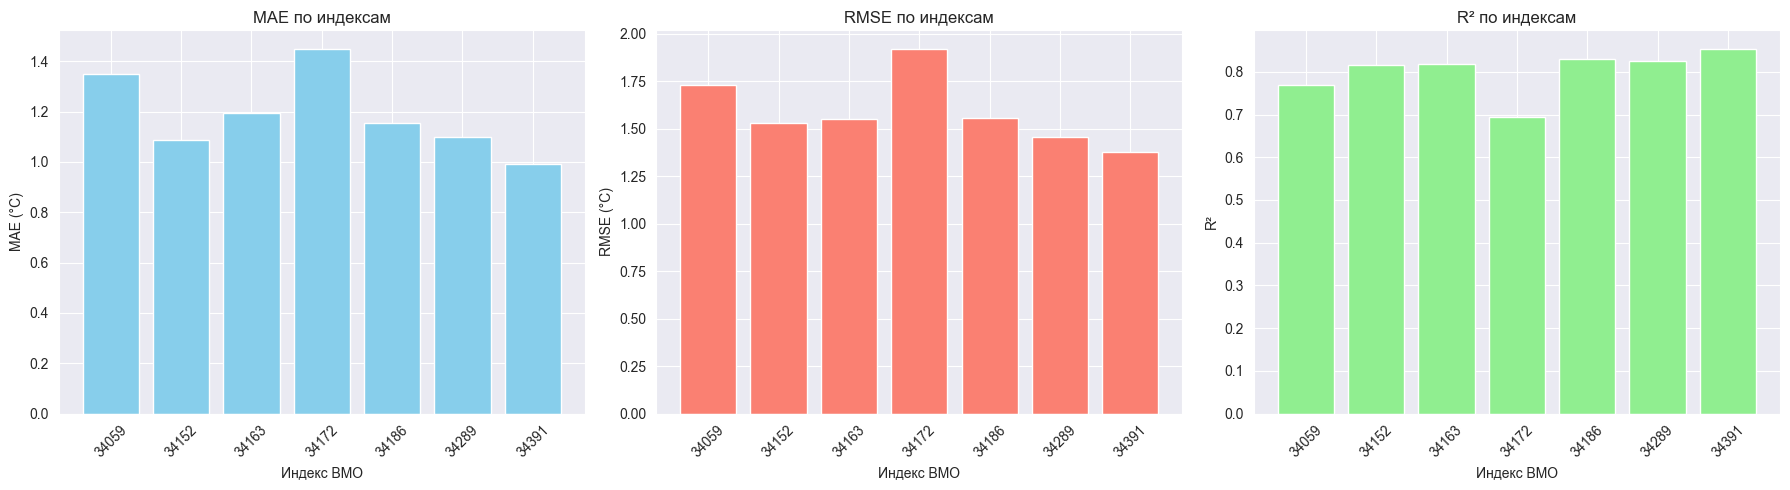

In [251]:
# mae_index_df = metrics_per_index(val_df, y_pred)

Для Саратова хуже всего

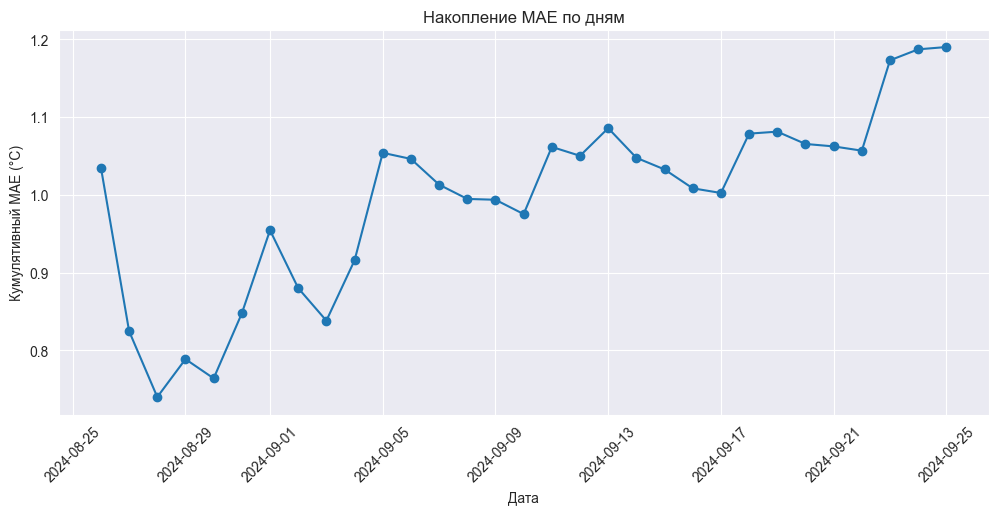

In [271]:
# cum_mae_df = cumulative_mae(val_df, y_pred)

                                              feature     importance
18           Температура поверхности почвы_short_lag1  190599.078125
1              Средняя температура воздуха_short_lag1   72896.937500
19      Парциальное давление водяного пара_short_lag1    2877.905518
21         Дефицит насыщения водяного пара_short_lag1    1414.080688
24     Характеристика барической тенденции_short_lag1    1250.786011
32             Общее количество облачности_short_lag2    1232.994751
34            Форма облаков верхнего яруса_short_lag2    1073.998779
6             Форма облаков верхнего яруса_short_lag1     793.158081
2                       Количество осадков_short_lag1     667.849426
12                    Погода между сроками_short_lag1     666.875244
50     Характеристика барической тенденции_short_lag2     655.344727
4              Общее количество облачности_short_lag1     613.127319
25           Величина барической тенденции_short_lag1     575.141846
17                           Сумма

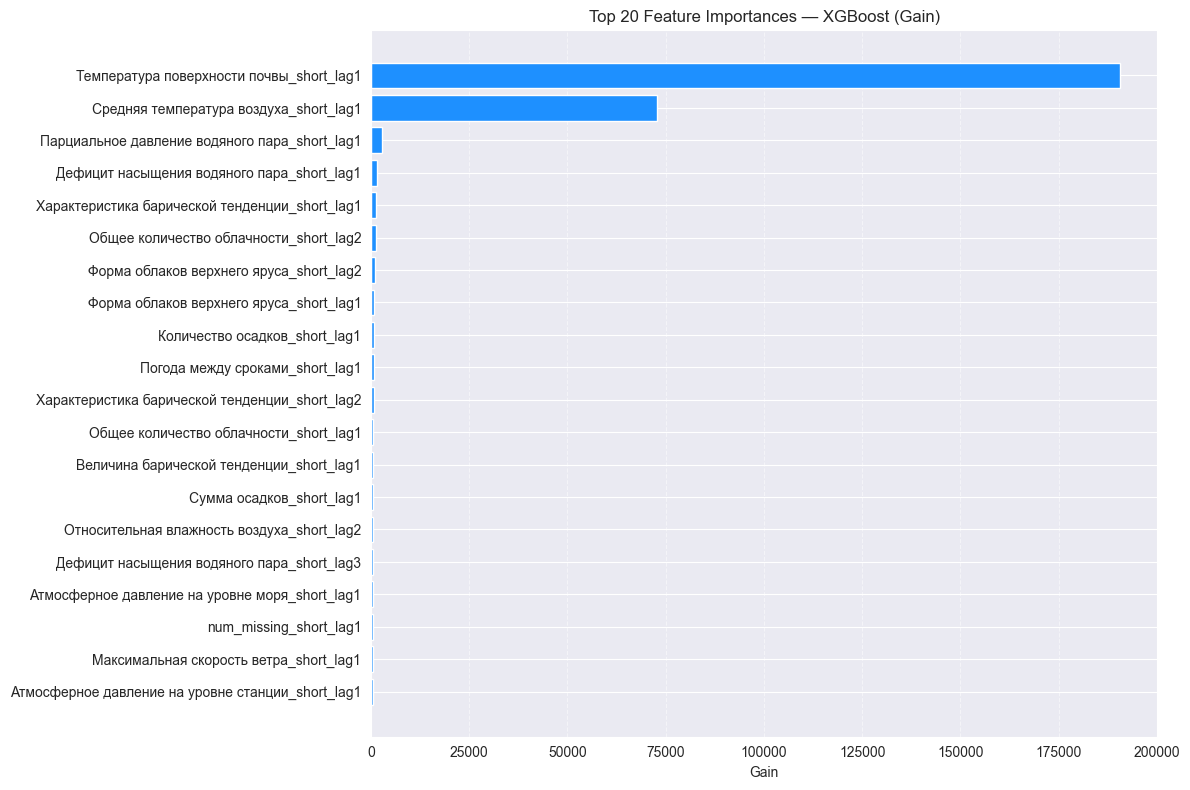

In [272]:
# # Если xgb_model — это Booster
# gain_importances = xgb_model.get_score(importance_type='gain')
#
# # Переводим в DataFrame
# fi_df = pd.DataFrame({
#     'feature': list(gain_importances.keys()),
#     'importance': list(gain_importances.values())
# }).sort_values(by='importance', ascending=False)
#
# # Топ-20 признаков
# fi_df_top20 = fi_df.head(20)
# print(fi_df_top20)
#
# # Визуализация
# plt.figure(figsize=(12, 8))
# plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
# plt.xlabel('Gain')
# plt.title('Top 20 Feature Importances — XGBoost (Gain)')
# plt.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

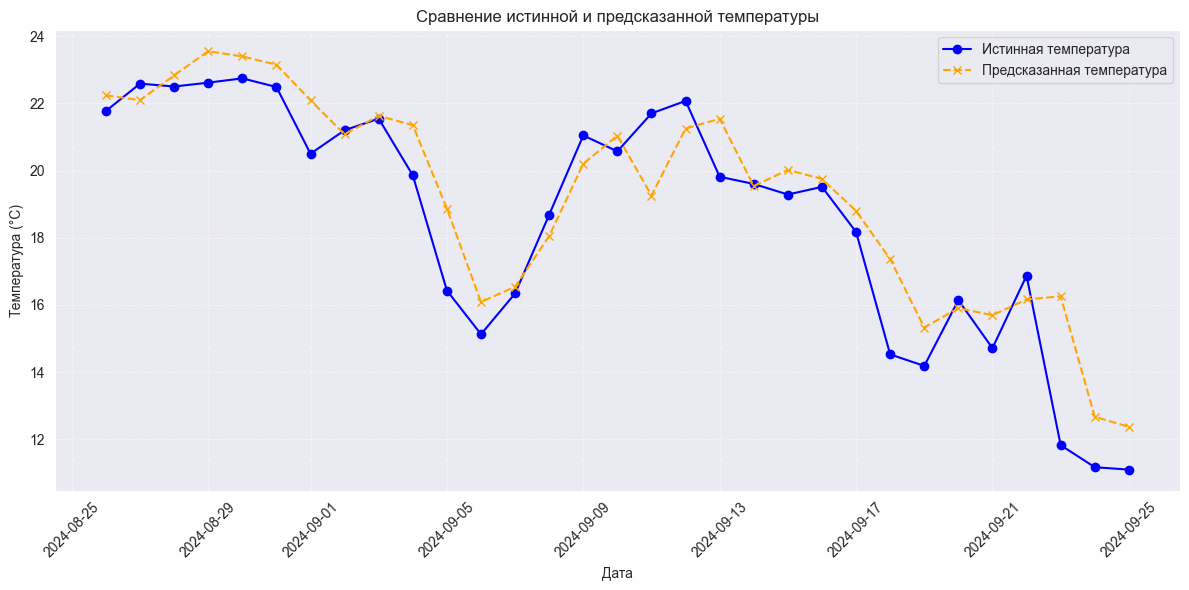

In [273]:
# plot_true_vs_pred(val_df, y_pred)

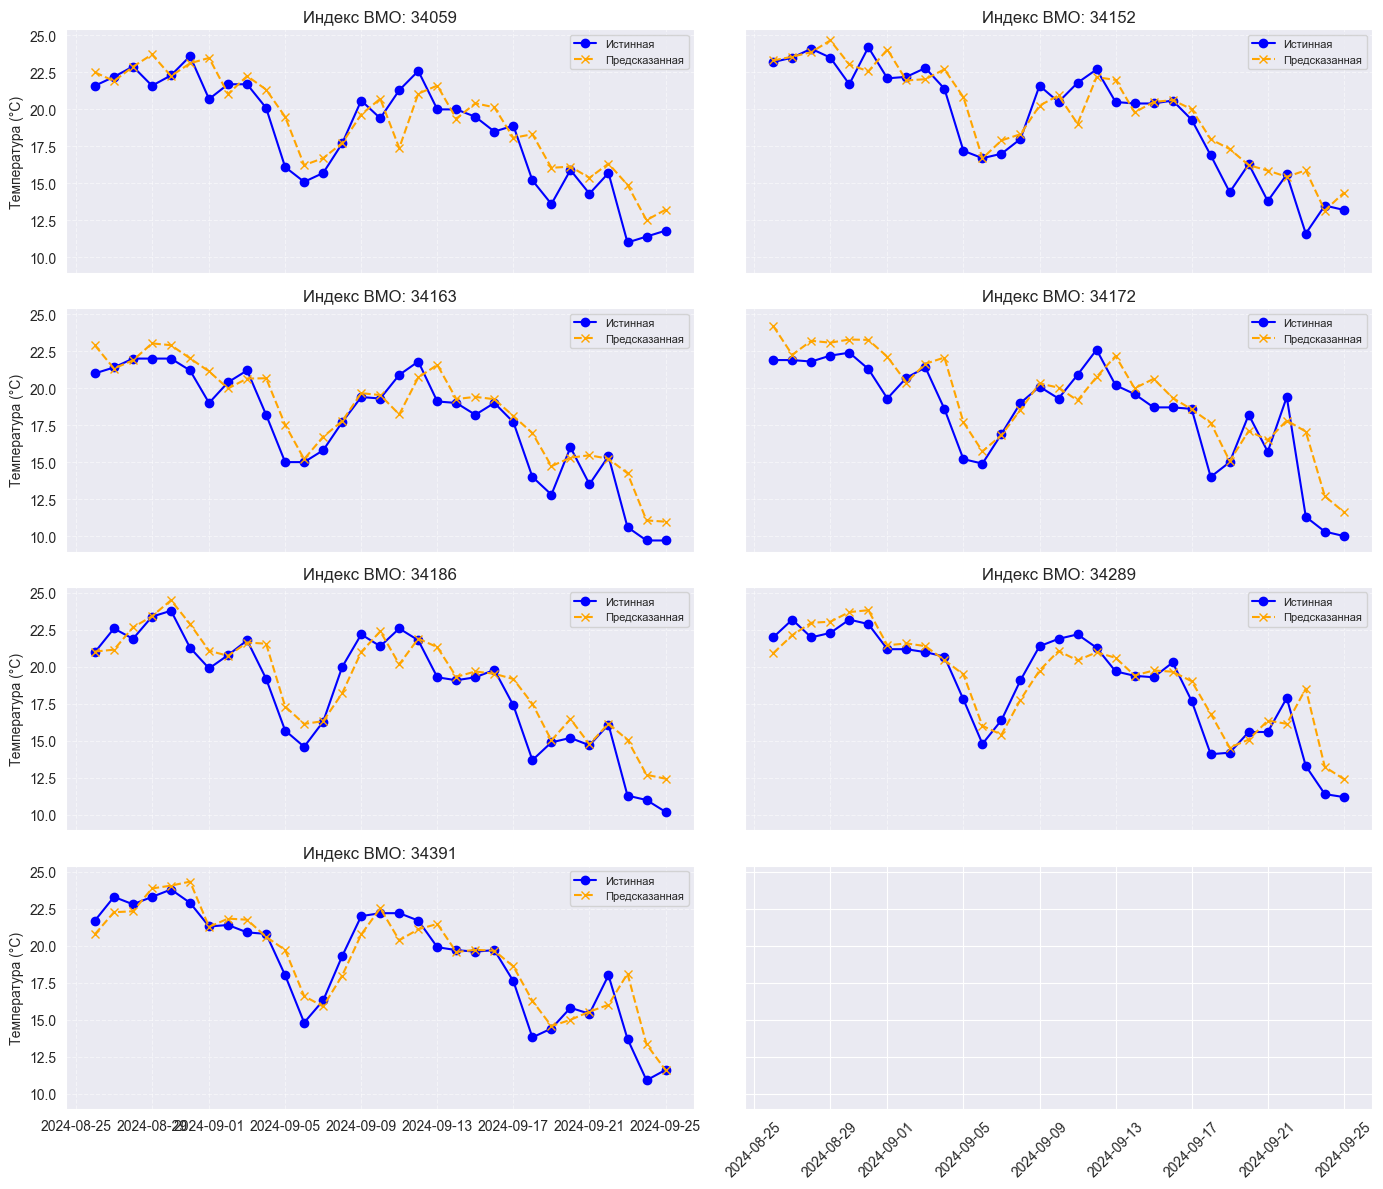

In [274]:
# plot_true_vs_pred_by_index(val_df, y_pred)

## LSTM

In [52]:
df_lstm = clean_lagged_df.copy()
df_lstm = df_lstm.sort_values(['Индекс ВМО', 'date'])
df_lstm

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.250,10.000,10.000,8.000,8.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,34059,1981-01-02,1.6,0.5,61.000,10.000,10.000,8.000,8.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34059,1981-01-03,-0.7,0.0,61.375,8.750,5.000,5.250,4.125,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,34059,1981-01-04,-2.5,0.0,52.375,8.875,5.125,5.375,4.250,1.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,34059,1981-01-05,-0.1,3.2,52.500,10.125,8.875,7.250,7.125,1.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111813,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111814,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111815,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111816,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    df_lstm.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111818 entries, 0 to 111817
Data columns (total 51 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       111818 non-null  int64         
 1   date                                             111818 non-null  datetime64[ns]
 2   Средняя температура воздуха                      111601 non-null  float64       
 3   Количество осадков                               111601 non-null  float64       
 4   Горизонтальная дальность видимости               111601 non-null  float64       
 5   Общее количество облачности                      111601 non-null  float64       
 6   Количество облачности нижнего яруса              111601 non-null  float64       
 7   Форма облаков верхнего яруса                     111601 non-null  float64       
 8   Форма облаков среднего я

In [415]:
# # Убираем лаги
# feature_cols = [col for col in df_lstm.columns
#                 if col not in [
#                     'date',
#                     'Индекс ВМО',
#                     'Средняя температура воздуха'
#                 ]
#                 and 'lag' not in col]
#
# target_col = 'Средняя температура воздуха'

In [411]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(df_lstm[feature_cols].isna().sum())

Количество осадков                                 217
Горизонтальная дальность видимости                 217
Общее количество облачности                        217
Количество облачности нижнего яруса                217
Форма облаков верхнего яруса                       217
Форма облаков среднего яруса                       217
Форма облаков вертикального развития               217
Слоистые и слоисто-кучевые облака                  217
Слоисто-дожд,разорванно-дождевые облака            217
Высота нижней границы облачности                   217
Погода между сроками                               217
Погода в срок наблюдения                           217
Направление ветра                                  217
Средняя скорость ветра                             217
Максимальная скорость ветра                        217
Сумма осадков                                      217
Температура поверхности почвы                      217
Парциальное давление водяного пара                 217
Относитель

Пропуски только для валидационной выборки

In [54]:
target_col = 'Средняя температура воздуха'

feature_cols = [col for col in df_lstm.columns
                if col not in ['date', 'Индекс ВМО']]

In [55]:
def create_sequences(df, feature_cols, target_col, window_size=7):
    X, y = [], []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        data = group[feature_cols].values
        target = group[target_col].values

        for i in range(len(group) - window_size):
            X.append(data[i:i+window_size])
            y.append(target[i+window_size])

    return np.array(X), np.array(y)

In [56]:
X, y = create_sequences(df_lstm, feature_cols, target_col, window_size=7)

In [417]:
train_df_lstm = df_lstm[df_lstm['date'] < val_start].copy()
val_df_lstm   = df_lstm[df_lstm['date'] >= val_start].copy()

In [421]:
def create_sequences(df, feature_cols, target_col, index_col='Индекс ВМО', seq_len=7):
    X, y = [], []
    for idx, group in df.groupby(index_col):
        group = group.sort_values('date')
        features = group[feature_cols].values
        target = group[target_col].values

        for i in range(len(group) - seq_len):
            X.append(features[i:i+seq_len])
            y.append(target[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 7  # последовательность на 7 дней

X_train_lstm, y_train_lstm = create_sequences(train_df_lstm, feature_cols, target_col, seq_len=SEQ_LEN)
X_val_lstm, y_val_lstm = create_sequences(val_df_lstm, feature_cols, target_col, seq_len=SEQ_LEN)

print("Train shape:", X_train_lstm.shape)
print("Val shape:", X_val_lstm.shape)

Train shape: (111531, 7, 48)
Val shape: (168, 7, 48)


In [422]:
scaler = StandardScaler()

# reshape для scaler: объединяем все последовательности в 2D
X_train_2d = X_train_lstm.reshape(-1, X_train_lstm.shape[2])
X_val_2d   = X_val_lstm.reshape(-1, X_val_lstm.shape[2])

# fit только на train!
scaler.fit(X_train_2d)

# применяем трансформацию и возвращаем 3D
X_train_scaled = scaler.transform(X_train_2d).reshape(X_train_lstm.shape)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val_lstm.shape)

In [423]:
model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)


y_pred = model.predict(X_val_scaled).flatten()


simple_metric(y_val, y_pred)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,041 (121.25 KB)

 Trainable params: 31,041 (121.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 8.3664 - mae: 1.9210 - val_loss: nan - val_mae: nan
Epoch 2/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4.3508 - mae: 1.5531 - val_loss: nan - val_mae: nan
Epoch 3/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4.0753 - mae: 1.5097 - val_loss: nan - val_mae: nan
Epoch 4/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.9097 - mae: 1.4822 - val_loss: nan - val_mae: nan
Epoch 5/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.7624 - mae: 1.4571 - val_loss: nan - val_mae: nan
Epoch 6/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.6380 - mae: 1.4354 - val_loss: nan - val_mae: nan
Epoch 7/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.5440 - mae: 1.4215 - val_loss: nan - val_mae: nan
Epoch 8/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.4543 - mae: 1.4044 - val_loss: nan - val_mae: nan
Epoch 9/20
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.3637 - mae: 1.390

ValueError: Input contains NaN.